This code presents the assessments of the method failed to be optimizied in the previous files: 


    APARACH - FIXED
    Student GARCH - FAILED PRE-2022
    EGARCH(1,1,1) - FAILED PRE-2022
    HARCH([5]) - that method is needed to a lesser extent
    

In [25]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt

from Vares_simulations import *

from Vares import _terminal_returns, historical_var

Vares.ENABLE_TIMING = False

import pickle

#import the USD data 
with open('prices_usd.pkl', 'rb') as f: 
    prices_usd = pickle.load(f)

with open('original_returns_usd.pkl', 'rb') as f: 
    original_returns_usd = pickle.load(f)

with open('log_returns_usd.pkl', 'rb') as f: 
    log_returns_usd = pickle.load(f)    

original_returns_usd_scaled = original_returns_usd * 100
log_returns_usd_scaled = log_returns_usd * 100

from GARCH_VaR_delete_or_merge import fit_GARCH_VaR

import pickle

with open("norm_vars.pkl", "rb") as f:
    _norm_vars = pickle.load(f)

def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta) * price for log_delta, price in zip(var_array, prices)]

In [102]:
def student_GARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=0, q=1, dist='t', rescale=False)
    results = model.fit(disp='off', options={'maxiter': 6000, 'eps': 1e-8})
    forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    simulator = make_random_path_simulator_local_vol_student(parameters, 10, nu, granularity=granularity)

    sim_returns = _terminal_returns(simulator=simulator, n_paths=n_paths) 
    # print(sim_returns[sim_returns < -0.9])

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

In [99]:
def EGARCHo1_simulation_tweaked(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='normal')
    # results = model.fit(disp='off', options={'maxiter': 100_000, 'eps': 1e-8, 'ftol': 1e-3})
    results = model.fit(disp='off', options={'maxiter': 100_000, 'eps': 1e-8})
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

def EGARCHo1_simulation_tweaked_2(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='normal')
    results = model.fit(disp='off', options={'maxiter': 1_000_000, 'ftol': 1e-4})
    # results = model.fit(disp='off', options={'maxiter': 100_000, 'eps': 1e-8})
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR




    
    EGARCH

In [100]:
egarch01_vars_scaled_2 = fit_GARCH_VaR(log_returns_usd_scaled, EGARCHo1_simulation_tweaked_2)

In [95]:
from GARCH_VaR_delete_or_merge import EGARCH_simulation

egarch_vars = fit_GARCH_VaR(log_returns_usd, EGARCH_simulation)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\P

In [85]:
egarch01_vars_scaled = fit_GARCH_VaR(log_returns_usd_scaled, EGARCHo1_simulation_tweaked)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\volatility.py:2792: RuntimeWarning:

overflow encountered in exp

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\mean.py:1000: RuntimeWarning:

invalid value encountered in dot

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\mean.py:1020: RuntimeWarning:

invalid value encountered in dot

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\volatility.py:2792: RuntimeWarning:

overflow encountered in exp

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\mean.py:1000: RuntimeWarning:

invalid value encountered in dot

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\mean.py:1020: RuntimeWarning:

invalid value encountered in dot



In [ ]:
student_vars = fit_GARCH_VaR(log_returns_usd, student_GARCH_simulation)
egarch01_vars = fit_GARCH_VaR(log_returns_usd, EGARCHo1_simulation)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequal

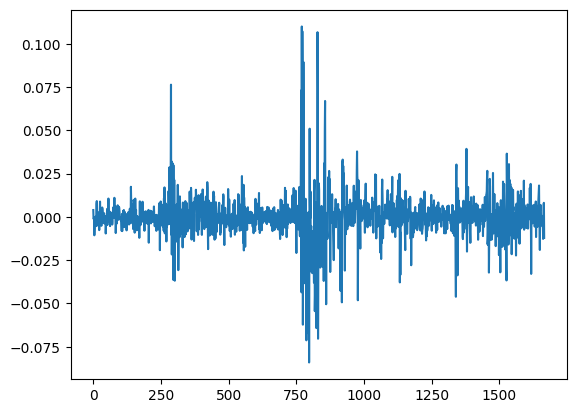

In [39]:
plt.plot(log_returns_usd)

In [101]:
_student_vars = np.multiply(student_vars, -1)
_egarch01_vars = np.multiply(egarch01_vars, -1)
_aparch_vars = np.multiply(aparch_vars, -1)
_egarch01_vars_scaled = np.multiply(egarch01_vars_scaled, -0.01)
_egarch01_vars_scaled_2 = np.multiply(egarch01_vars_scaled_2, -0.01)
_egarch_vars = np.multiply(egarch_vars, -1)

import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# # Add GARCH(1,1)
# fig.add_trace(go.Scatter(
#     x=np.arange(len(prices_usd)),
#     y=turn_var_into_real_terms(_norm_vars, prices_usd),
#     mode='lines',
#     line=dict(color='red', width=0.5),
#     name='GARCH(1, 1)'
# ))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_egarch01_vars_scaled_2, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='EGARCH(1,1,1) scaled'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_egarch01_vars_scaled, prices_usd),
    mode='lines',
    line=dict(color='blue', width=0.5),
    name='EGARCH(1,1,1) scaled stable'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_egarch_vars, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='EGARCH(1,0,1)'
))

# fig.add_trace(go.Scatter(
#     x=np.arange(len(prices_usd)),
#     y=turn_var_into_real_terms(_tarch_vars, prices_usd),
#     mode='lines',
#     line=dict(color='brown', width=0.5),
#     name='TARCH(1,1)'
# ))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


    APARCH

In [ ]:
def APARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='APARCH', p=1, o=1, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return 

def APARCH_simulation_2(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='APARCH', p=1, o=1, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR



In [107]:
aparch_vars_scaled = fit_GARCH_VaR(log_returns_usd_scaled, APARCH_simulation)
_aparch_vars_scaled = np.multiply(aparch_vars_scaled, -0.01)

In [104]:
aparch_vars = fit_GARCH_VaR(log_returns_usd, APARCH_simulation)
_aparch_vars = np.multiply(aparch_vars, -1)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\P

In [109]:
_student_vars = np.multiply(student_vars, -1)
_egarch01_vars = np.multiply(egarch01_vars, -1)
_aparch_vars = np.multiply(aparch_vars, -1)
_egarch01_vars_scaled = np.multiply(egarch01_vars_scaled, -0.01)
_egarch01_vars_scaled_2 = np.multiply(egarch01_vars_scaled_2, -0.01)
_egarch_vars = np.multiply(egarch_vars, -1)

import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# # Add GARCH(1,1)
# fig.add_trace(go.Scatter(
#     x=np.arange(len(prices_usd)),
#     y=turn_var_into_real_terms(_norm_vars, prices_usd),
#     mode='lines',
#     line=dict(color='red', width=0.5),
#     name='GARCH(1, 1)'
# ))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='GARCH(1,1)'
))

#фейлится в двух местах
# fig.add_trace(go.Scatter(
#     x=np.arange(len(prices_usd)),
#     y=turn_var_into_real_terms(_aparch_vars, prices_usd),
#     mode='lines',
#     line=dict(color='blue', width=0.5),
#     name='APARCH(1,1,1)'
# ))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_egarch_vars, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='APARCH(1,1,1) scaled'
))

# fig.add_trace(go.Scatter(
#     x=np.arange(len(prices_usd)),
#     y=turn_var_into_real_terms(_tarch_vars, prices_usd),
#     mode='lines',
#     line=dict(color='brown', width=0.5),
#     name='TARCH(1,1)'
# ))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()



    STUDENT GARCH 

In [ ]:
def student_GARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=0, q=1, dist='t', rescale=False)
    # results = model.fit(disp='off', options={'maxiter': 6000, 'eps': 1e-8})
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    simulator = make_random_path_simulator_local_vol_student(parameters, 10, nu, granularity=granularity)

    sim_returns = _terminal_returns(simulator=simulator, n_paths=n_paths) 
    # print(sim_returns[sim_returns < -0.9])

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

In [139]:
student_vars_scaled = fit_GARCH_VaR(log_returns_usd_scaled, student_GARCH_simulation)
_student_vars_scaled = np.multiply(student_vars_scaled, -0.01)

In [117]:
student_vars_orig = fit_GARCH_VaR(log_returns_usd, student_GARCH_simulation)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivati

In [118]:
student_vars = fit_GARCH_VaR(log_returns_usd, student_GARCH_simulation)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivati

In [142]:
_student_vars_orig = np.multiply(student_vars_orig, -1)

# _student_vars_scaled_2 = _student_vars_scaled
# _student_vars_scaled_2[434] = 0 
# _student_vars_scaled_2[805] = 0 
# _student_vars_scaled_2[653] = 0 
# _student_vars_scaled_2[763] = 0 

_student_vars_orig[545] = 0 
_student_vars_orig[653] = 0 
_student_vars_orig[763] = 0 
_student_vars_orig[1334] = 0 
_student_vars_orig[1408] = 0 




import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# # Add GARCH(1,1)
# fig.add_trace(go.Scatter(
#     x=np.arange(len(prices_usd)),
#     y=turn_var_into_real_terms(_norm_vars, prices_usd),
#     mode='lines',
#     line=dict(color='red', width=0.5),
#     name='GARCH(1, 1)'
# ))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='GARCH(1,1)'
))

# фейлится в двух местах
# fig.add_trace(go.Scatter(
#     x=np.arange(len(prices_usd)),
#     y=turn_var_into_real_terms(_student_vars, prices_usd),
#     mode='lines',
#     line=dict(color='blue', width=0.5),
#     name='APARCH(1,1,1)'
# ))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_student_vars_scaled, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='Student scaled'
))

# fig.add_trace(go.Scatter(
#     x=np.arange(len(prices_usd)),
#     y=turn_var_into_real_terms(_student_vars_orig, prices_usd),
#     mode='lines',
#     line=dict(color='brown', width=0.5),
#     name='Student original'
# ))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


In [161]:
def student_EGARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='EGARCH', p=1, o=0, q=1, dist='t', rescale=False)
    # results = model.fit(disp='off', options={'maxiter': 6000, 'eps': 1e-8})
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    simulator = make_random_path_simulator_local_vol_student(parameters, 10, nu, granularity=granularity)

    sim_returns = _terminal_returns(simulator=simulator, n_paths=n_paths) 
    # print(sim_returns[sim_returns < -0.9])

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

def student_FIGARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='FIGARCH', p=1, o=0, q=1, dist='t', rescale=False)
    results = model.fit(disp='off', options={'maxiter': 6000, 'eps': 1e-8})
    # results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    simulator = make_random_path_simulator_local_vol_student(parameters, 10, nu, granularity=granularity)

    sim_returns = _terminal_returns(simulator=simulator, n_paths=n_paths) 
    # print(sim_returns[sim_returns < -0.9])

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

def student_TARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, power=1.0, q=1, dist='t')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    # sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    simulator = make_random_path_simulator_local_vol_student(parameters, 10, nu, granularity=granularity)

    sim_returns = _terminal_returns(simulator=simulator, n_paths=n_paths) 

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

def student_GJRGARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=1, q=1, dist='t')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    # sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    simulator = make_random_path_simulator_local_vol_student(parameters, 10, nu, granularity=granularity)

    sim_returns = _terminal_returns(simulator=simulator, n_paths=n_paths) 

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

In [148]:
t_egarch_vars = fit_GARCH_VaR(log_returns_usd_scaled, student_EGARCH_simulation)
t_tarch_vars = fit_GARCH_VaR(log_returns_usd_scaled, student_TARCH_simulation)
t_gjrgarjch_vars = fit_GARCH_VaR(log_returns_usd_scaled, student_GJRGARCH_simulation)
t_figarch_vars = fit_GARCH_VaR(log_returns_usd_scaled, student_FIGARCH_simulation)

In [162]:
t_tarch_vars = fit_GARCH_VaR(log_returns_usd_scaled, student_TARCH_simulation)
t_gjrgarjch_vars = fit_GARCH_VaR(log_returns_usd_scaled, student_GJRGARCH_simulation)
t_egarch_vars = fit_GARCH_VaR(log_returns_usd_scaled, student_EGARCH_simulation)

In [167]:
_t_egarch_vars = np.multiply(t_egarch_vars, -0.01)
_t_tarch_vars = np.multiply(t_tarch_vars, -0.01)
_t_gjrgarjch_vars = np.multiply(t_gjrgarjch_vars, -0.01)
_t_figarch_vars = np.multiply(t_figarch_vars, -0.01)

In [168]:
import plotly.graph_objects as go



# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add GARCH(1,1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='red', width=0.5),
    name='GARCH(1, 1)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_t_tarch_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='TARCH(1,1) (S)'
))


fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_t_figarch_vars, prices_usd),
    mode='lines',
    line=dict(color='blue', width=0.5),
    name='FIGARCH(1,1) S)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_t_egarch_vars, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='EGARCH(1,0,1) (S)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_t_gjrgarjch_vars, prices_usd),
    mode='lines',
    line=dict(color='brown', width=0.5),
    name='GJR-GARCH(1,1,1) (S)'
))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=800,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


In [169]:
import plotly.graph_objects as go



# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add GARCH(1,1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='red', width=0.5),
    name='GARCH(1, 1)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_t_tarch_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='TARCH(1,1) (S)'
))


fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_t_figarch_vars, prices_usd),
    mode='lines',
    line=dict(color='blue', width=0.5),
    name='FIGARCH(1,1) S)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_student_vars_scaled, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='GARCH(1,1) (S)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_t_gjrgarjch_vars, prices_usd),
    mode='lines',
    line=dict(color='brown', width=0.5),
    name='GJR-GARCH(1,1,1) (S)'
))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=800,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()
